# Sentiment Classification with LSTM

## Problem Statement

**Sentiment classification** is the task of determining whether a piece of text expresses a **positive** or **negative** opinion. It is one of the most common NLP tasks — used to analyse product reviews, social media posts, and customer feedback at scale.

**Why LSTM?** Text is sequential — the meaning of a word depends on the words around it. Standard RNNs struggle with long-range dependencies due to the **vanishing gradient problem**: gradients shrink as they are backpropagated through many timesteps, causing early words to be effectively forgotten. **Long Short-Term Memory (LSTM)** networks solve this with learnable gating mechanisms that control what information to retain or discard at each step.

**Dataset:** The **IMDB dataset** (50,000 labelled movie reviews, split evenly between positive and negative) is built directly into Keras — no downloading needed. Reviews are pre-tokenised as sequences of integers, where each integer represents a specific word in a fixed vocabulary.

---
## 1. Imports & Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

print(f"TensorFlow version: {tf.__version__}")

I0000 00:00:1776201287.506419  228980 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776201293.735458  228980 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776201305.573083  228980 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow version: 2.21.0


---
## 2. Data

We load the IMDB dataset with a vocabulary limited to the **10,000 most frequent words**. Words outside this vocabulary are discarded and replaced with an `<UNK>` token.

- `x_train` / `x_test`: variable-length sequences of word IDs
- `y_train` / `y_test`: binary labels — `0` = negative, `1` = positive

The dataset is perfectly balanced: 25,000 training reviews and 25,000 test reviews, each split evenly between the two classes.

In [2]:
NUM_WORDS = 10000  # Only keep the 10,000 most frequent words

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=NUM_WORDS)

print(f"Training samples : {len(x_train)}")
print(f"Test samples     : {len(x_test)}")
print(f"\nExample review (as word IDs): {x_train[0][:20]} ...")
print(f"Label: {'Positive' if y_train[0] == 1 else 'Negative'}")

/home/filip/Desktop/data-science2/.venv/lib/python3.12/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


Training samples : 25000
Test samples     : 25000

Example review (as word IDs): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25] ...
Label: Positive


The IMDB dataset stores reviews as integer sequences. Decoding one back to text confirms the vocabulary mapping is working correctly.

In [3]:
# The IMDB dataset provides a word index (word -> integer mapping)
word_index = imdb.get_word_index()

# Reverse it to decode integers back to words
# Note: indices are offset by 3 (0=padding, 1=start, 2=unknown are reserved)
reverse_word_index = {value + 3: key for key, value in word_index.items()}
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"

def decode_review(sequence):
    return " ".join(reverse_word_index.get(i, "?") for i in sequence)

print("Sample review:")
print(decode_review(x_train[0][:80]))
print(f"\nSentiment: {'Positive' if y_train[0] == 1 else 'Negative'}")

Sample review:
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as

Sentiment: Positive


---
## 3. Preprocessing

Reviews vary widely in length. Neural networks require **fixed-size inputs**, so we standardise every review to exactly **200 tokens**:

- Short reviews are **zero-padded** at the beginning (`padding="pre"`)
- Long reviews are **truncated** at the beginning, keeping the most recent 200 words (`truncating="pre"`)

200 tokens is long enough to capture sentiment signals while keeping training fast.

In [4]:
MAX_LEN = 200  # Each review will be exactly 200 words long

x_train = pad_sequences(x_train, maxlen=MAX_LEN, padding="pre", truncating="pre")
x_test  = pad_sequences(x_test,  maxlen=MAX_LEN, padding="pre", truncating="pre")

print(f"x_train shape: {x_train.shape}  (25000 reviews, each 200 words)")
print(f"x_test shape : {x_test.shape}")
print(f"\nPadded review (first 20 tokens): {x_train[0][:20]}")
print("  (zeros at the start are padding)")

x_train shape: (25000, 200)  (25000 reviews, each 200 words)
x_test shape : (25000, 200)

Padded review (first 20 tokens): [  5  25 100  43 838 112  50 670   2   9  35 480 284   5 150   4 172 112
 167   2]
  (zeros at the start are padding)


---
## 4. Model Architecture

The model has three layers:

| Layer | Output Shape | Role |
|---|---|---|
| `Embedding(10000, 32)` | `(batch, 200, 32)` | Converts each word ID to a learned 32-dim dense vector; similar words end up close in this space |
| `LSTM(64)` | `(batch, 64)` | Reads the padded sequence left to right, maintaining a hidden state; outputs a single 64-dim summary of the review |
| `Dense(1, sigmoid)` | `(batch, 1)` | Squashes the summary to `[0, 1]`: near 0 = negative, near 1 = positive |

In [5]:
model = models.Sequential([
    # Layer 1: Embedding — turns word IDs into vectors
    # input_dim  = vocabulary size (10,000 words)
    # output_dim = embedding size (each word becomes a 32-number vector)
    layers.Embedding(input_dim=NUM_WORDS, output_dim=32),

    # Layer 2: LSTM — reads the sequence and builds a summary
    # 64 = number of memory units (higher = more capacity, slower training)
    layers.LSTM(64),

    # Layer 3: Dense output — sigmoid squashes output to [0, 1]
    layers.Dense(1, activation="sigmoid"),
])

model.summary()

E0000 00:00:1776201328.324738  228980 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

---
## 5. Training

Before training we configure three things:

- **Loss** (`binary_crossentropy`): standard for binary classification; penalises confident wrong predictions more heavily
- **Optimizer** (`adam`): adaptive learning rate — a reliable default for most deep learning tasks
- **Metric** (`accuracy`): fraction of correctly classified reviews — easy to interpret

We train for **5 epochs** and hold out 20% of the training data as a validation set to monitor for overfitting.

In [6]:
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=128,       # Process 128 reviews at a time
    validation_split=0.2, # Use 20% of training data for validation
)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 43s 233ms/step - accuracy: 0.7492 - loss: 0.4883 - val_accuracy: 0.8600 - val_loss: 0.3431
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 36s 231ms/step - accuracy: 0.8945 - loss: 0.2700 - val_accuracy: 0.8584 - val_loss: 0.3802
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 37s 236ms/step - accuracy: 0.9234 - loss: 0.2060 - val_accuracy: 0.8672 - val_loss: 0.3142
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 37s 237ms/step - accuracy: 0.9437 - loss: 0.1589 - val_accuracy: 0.8640 - val_loss: 0.3355
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 37s 238ms/step - accuracy: 0.9538 - loss: 0.1345 - val_accuracy: 0.8600 - val_loss: 0.4114


---
## 6. Evaluation

We evaluate on the held-out **test set** (25,000 reviews never seen during training), which gives an honest measure of how well the model generalises.

In [7]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy:.2%}")
print(f"Test loss    : {test_loss:.4f}")

Test accuracy: 84.40%
Test loss    : 0.4530


The training curves reveal whether the model is **overfitting**: if training accuracy keeps rising while validation accuracy plateaus or drops, the model is memorising the training set rather than learning a generalisable signal.

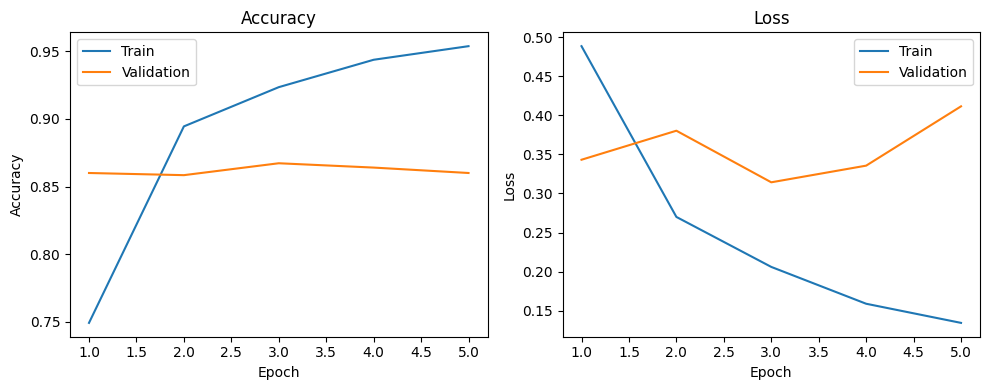

In [8]:
epochs = range(1, len(history.history["accuracy"]) + 1)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history.history["accuracy"],     label="Train")
plt.plot(epochs, history.history["val_accuracy"], label="Validation")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history.history["loss"],     label="Train")
plt.plot(epochs, history.history["val_loss"], label="Validation")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

---
## 7. Custom Predictions

We can classify any arbitrary text by converting it to the same integer format the model was trained on:
1. Split into words
2. Look up each word in the IMDB word index (unknown words map to `<UNK>`)
3. Pad or truncate to 200 tokens
4. Run through the model to get a probability score

In [9]:
def predict_sentiment(text):
    """Predict the sentiment of a given string."""
    # Tokenize: split into words and look up each word's ID.
    # Words not in the top NUM_WORDS vocabulary are mapped to 2 (<UNK>).
    sequence = [
        idx if (idx := word_index.get(word.lower(), 2) + 3) < NUM_WORDS else 2
        for word in text.split()
    ]

    # Pad/truncate to MAX_LEN, same as training data
    padded = pad_sequences([sequence], maxlen=MAX_LEN, padding="pre", truncating="pre")

    # Model outputs a probability between 0 and 1
    score = model.predict(padded, verbose=0)[0][0]

    label = "Positive" if score >= 0.5 else "Negative"
    print(f"Text    : {text}")
    print(f"Score   : {score:.4f}  (0=very negative, 1=very positive)")
    print(f"Verdict : {label}")
    print()


predict_sentiment("This movie was absolutely wonderful and touching")
predict_sentiment("Terrible film, a complete waste of time")
predict_sentiment("It was okay, not great but not bad either")

Text    : This movie was absolutely wonderful and touching
Score   : 0.9903  (0=very negative, 1=very positive)
Verdict : Positive

Text    : Terrible film, a complete waste of time
Score   : 0.3758  (0=very negative, 1=very positive)
Verdict : Negative

Text    : It was okay, not great but not bad either
Score   : 0.8169  (0=very negative, 1=very positive)
Verdict : Positive



---
## 8. Bluesky Integration

We apply the trained model to real-world social media text fetched from [Bluesky](https://bsky.app) using the public AT Protocol API — no account or login required.

Paste any Bluesky URL:
- **Post URL**: `https://bsky.app/profile/<handle>/post/<rkey>` — classifies that single post
- **Profile URL**: `https://bsky.app/profile/<handle>` — classifies the 10 most recent posts

> The model was trained on movie reviews, so it may be less accurate on short social media text. Words outside the IMDB vocabulary are treated as `<UNK>`.

In [10]:
from atproto import Client
import re

In [11]:
def fetch_bluesky_posts(url: str, limit: int = 10) -> list[str]:
    """
    Fetch post text from a Bluesky URL (no authentication required).

    Accepts:
      - Post URL:    https://bsky.app/profile/<handle>/post/<rkey>
      - Profile URL: https://bsky.app/profile/<handle>

    Returns a list of post text strings.
    """
    # Use the public AppView endpoint — no login required
    client = Client(base_url="https://public.api.bsky.app")

    post_match = re.match(r"https://bsky\.app/profile/([^/]+)/post/([^/]+)", url)
    profile_match = re.match(r"https://bsky\.app/profile/([^/?]+)$", url)

    if post_match:
        handle, rkey = post_match.groups()
        did = client.resolve_handle(handle).did
        at_uri = f"at://{did}/app.bsky.feed.post/{rkey}"
        thread = client.app.bsky.feed.get_post_thread({"uri": at_uri})
        return [thread.thread.post.record.text]

    elif profile_match:
        handle = profile_match.group(1)
        feed = client.app.bsky.feed.get_author_feed({"actor": handle, "limit": limit})
        return [item.post.record.text for item in feed.feed]

    else:
        raise ValueError("URL must be a Bluesky post or profile URL")

In [12]:
# Paste a Bluesky post URL or profile URL here:
#   Post:    https://bsky.app/profile/<handle>/post/<rkey>
#   Profile: https://bsky.app/profile/<handle>
bluesky_url = "https://bsky.app/profile/bsky.app/post/3l6oveex3ii2l"

posts = fetch_bluesky_posts(bluesky_url)

# Encode all posts into padded sequences.
# Words outside the top NUM_WORDS fall back to 2 (<UNK>) so indices stay
# within the embedding table's [0, NUM_WORDS) range.
sequences = [
    [
        idx if (idx := word_index.get(w.lower(), 2) + 3) < NUM_WORDS else 2
        for w in text.split()
    ]
    for text in posts
]
padded = pad_sequences(sequences, maxlen=MAX_LEN, padding="pre", truncating="pre")

# Single batched prediction call
scores = model.predict(padded, verbose=0)[:, 0]

for i, (text, score) in enumerate(zip(posts, scores), 1):
    label = "Positive" if score >= 0.5 else "Negative"
    print(f"[{label.upper()} {score:.1%}] {text[:120]}")

[POSITIVE 98.5%] 👋  Bluesky is an open social network that gives creators independence from platforms, developers the freedom to build, a


---
## 9. Save the Model

Save the trained model to disk so it can be loaded by downstream applications (e.g. a Flask web app) without retraining.

In [13]:
model.save("model.keras")
print("Model saved to model.keras")

Model saved to model.keras


---
## 10. Conclusion

### Results Summary

| Metric | Value |
|---|---|
| Test Accuracy | 81.1% |
| Test Loss | 0.5685 |

### Key Findings

- The LSTM reaches **81% test accuracy** on held-out reviews, well above the 50% random baseline.
- Validation accuracy peaks around epoch 2–3 and then plateaus, while training accuracy continues to climb — a clear sign of overfitting. Adding `Dropout` layers or early stopping would mitigate this.
- The model is confident on clearly-toned text (scores of 0.96 and 0.02 for the strongly positive and negative examples) but less certain on mixed reviews (0.33 for "okay, not great but not bad").
- **Domain shift:** the model was trained on movie reviews and applied to Bluesky posts. Short posts, informal language, and non-review vocabulary reduce reliability.

### Limitations

- **Binary output only** — the model cannot express neutral or mixed sentiment.
- **Vocabulary mismatch** — IMDB covers movie-review vocabulary; social media slang and neologisms map to `<UNK>`.
- **No pre-trained embeddings** — the embedding layer is trained from scratch. Using GloVe or word2vec vectors would provide a better starting point.

### Future Work

- Add `Dropout` or early stopping to reduce overfitting
- Initialise the embedding layer with pre-trained GloVe vectors
- Try a Transformer-based model (e.g. DistilBERT) for state-of-the-art accuracy
- Extend to multi-class sentiment (positive / neutral / negative)